# Exercice 2.2 : Détection de Densité (DBSCAN)
Dans cet atelier, nous explorons le clustering par densité avec DBSCAN.

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

data = pd.read_csv('data/UNSW_NB15_training-set.csv')
features = data.copy().sample(frac=0.1, random_state=42)  # Échantillon de 10% pour accélérer le traitement
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))

X_scaled = StandardScaler().fit_transform(features)
#X_scaled = features

X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
print("Données prêtes :", X_scaled.shape)

Données prêtes : (8233, 45)


C:\Users\Lucas\AppData\Local\Temp\ipykernel_19172\3357312335.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features.select_dtypes(include=['object']).columns:


Points classés comme bruit (-1, outliers) : 1019 flux (12.4%)


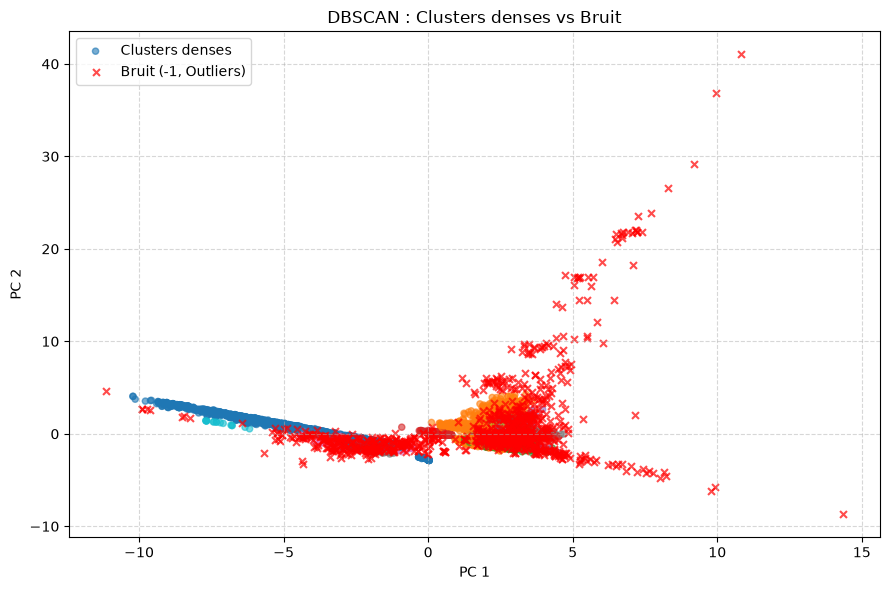

In [2]:
from sklearn.cluster import DBSCAN
from helper import plot_dbscan_scatter

eps = 2 # Rayon
min_samples = 15 # Nombre de sample dans ce dernier pour valider

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
n_bruit = (db.labels_ == -1).sum()
print(f"Points classés comme bruit (-1, outliers) : {n_bruit} flux ({n_bruit/len(X_scaled)*100:.1f}%)")

plot_dbscan_scatter(X_2d, db.labels_)